# Assignment 4: Heap Data Structures Implementation, Analysis, and Applications
## Part 1A: Heapsort Implementation

**Name:** Sai Venkata Bharath Reddy Singareddy

### Goal
The goal of this part is to implement the Heapsort algorithm using Python.

### Process Followed
I implemented Heapsort in three stages:

1. **heapify**
   - This function restores the max-heap property for a subtree.
2. **build_max_heap**
   - This function converts an unsorted array into a valid max-heap.
3. **heapsort**
   - This function repeatedly moves the maximum element to the end of the array and restores the heap property on the remaining elements.

I used a Python list to represent the binary heap because array/list representation is the standard way to implement heaps efficiently. It allows easy index-based access to parent and child nodes.

Before moving to analysis, I also included correctness tests for:
- empty arrays
- single-element arrays
- sorted arrays
- reverse-sorted arrays
- arrays with repeated values
- arrays with negative values

In [1]:
"""
Assignment 4
Part 1A: Heapsort Implementation

Name: Sai Venkata Bharath Reddy Singareddy

Purpose:
This code implements Heapsort using a binary max-heap stored in a Python list.

What this implementation shows:
1. How to maintain the heap property with heapify
2. How to build a max-heap from an unsorted array
3. How Heapsort repeatedly extracts the maximum element
4. Basic tests to verify correctness

Design choice:
The heap is stored in a Python list because list/array representation is the
standard and most efficient way to implement a binary heap.

Index formulas:
- left child  = 2*i + 1
- right child = 2*i + 2
- parent      = (i - 1) // 2
"""


def heapify(arr, heap_size, root_index):
    """
    Restore the max-heap property for the subtree rooted at root_index.

    Parameters:
        arr (list): The array representing the heap
        heap_size (int): Number of elements currently in the heap
        root_index (int): Index of the subtree root

    How it works:
    - Compare the root with its left and right children
    - Identify the largest among the three
    - If the root is not the largest, swap it with the largest child
    - Recursively heapify the affected subtree

    Time complexity:
        O(log n) in the worst case
    """

    # Assume the current root is the largest
    largest = root_index

    # Compute left and right child indices
    left_child = 2 * root_index + 1
    right_child = 2 * root_index + 2

    # Check if left child exists and is greater than current largest
    if left_child < heap_size and arr[left_child] > arr[largest]:
        largest = left_child

    # Check if right child exists and is greater than current largest
    if right_child < heap_size and arr[right_child] > arr[largest]:
        largest = right_child

    # If the largest value is not at the root, swap and continue heapifying
    if largest != root_index:
        arr[root_index], arr[largest] = arr[largest], arr[root_index]

        # Recursively restore the heap property in the affected subtree
        heapify(arr, heap_size, largest)


def build_max_heap(arr):
    """
    Convert an unsorted array into a max-heap in place.

    Parameters:
        arr (list): Input array

    How it works:
    - Start from the last non-leaf node
    - Move backward toward the root
    - Heapify each subtree

    Why this works:
    Leaf nodes are already valid heaps of size 1, so only internal nodes
    need to be fixed.

    Time complexity:
        O(n)
    """

    n = len(arr)

    # The last internal node is at index (n // 2) - 1
    for i in range(n // 2 - 1, -1, -1):
        heapify(arr, n, i)


def heapsort(input_arr):
    """
    Sort a list in ascending order using Heapsort.

    Parameters:
        input_arr (list): Input list to sort

    Returns:
        list: A new sorted list

    Main steps:
    1. Build a max-heap
    2. Swap the root (maximum value) with the last element
    3. Reduce the heap size by 1
    4. Heapify the root again
    5. Repeat until the heap becomes size 1

    Time complexity:
        O(n log n) in best, average, and worst cases
    """

    # Work on a copy to avoid modifying the original input
    arr = input_arr.copy()
    n = len(arr)

    # Step 1: Build a max-heap
    build_max_heap(arr)

    # Step 2: Repeatedly extract the maximum element
    for end_index in range(n - 1, 0, -1):
        # Move the current maximum to its correct final position
        arr[0], arr[end_index] = arr[end_index], arr[0]

        # Restore the max-heap property in the reduced heap
        heapify(arr, end_index, 0)

    return arr


def is_sorted(arr):
    """
    Check whether a list is sorted in non-decreasing order.

    Parameters:
        arr (list): List to check

    Returns:
        bool: True if sorted, False otherwise
    """
    for i in range(1, len(arr)):
        if arr[i] < arr[i - 1]:
            return False
    return True


def run_heapsort_tests():
    """
    Run basic correctness tests for Heapsort.

    Test coverage:
    - empty list
    - single-element list
    - normal unsorted list
    - already sorted list
    - reverse-sorted list
    - repeated values
    - negative numbers
    """

    test_cases = [
        [],
        [5],
        [3, 1, 4, 1, 5, 9, 2],
        [1, 2, 3, 4, 5],
        [5, 4, 3, 2, 1],
        [7, 7, 7, 7],
        [10, -2, 8, 0, -5, 3],
        [12, 11, 13, 5, 6, 7]
    ]

    print("Running Heapsort correctness tests...\n")

    for i, test in enumerate(test_cases, start=1):
        result = heapsort(test)
        expected = sorted(test)

        print(f"Test Case {i}: {test}")
        print(f"Sorted Result : {result}")
        print(f"Expected      : {expected}")

        assert result == expected, f"Heapsort failed on test case {i}"
        assert is_sorted(result), f"Output is not sorted for test case {i}"

        print("Status        : Passed\n")

    print("All Heapsort tests passed successfully.")


# Run correctness tests
run_heapsort_tests()

Running Heapsort correctness tests...

Test Case 1: []
Sorted Result : []
Expected      : []
Status        : Passed

Test Case 2: [5]
Sorted Result : [5]
Expected      : [5]
Status        : Passed

Test Case 3: [3, 1, 4, 1, 5, 9, 2]
Sorted Result : [1, 1, 2, 3, 4, 5, 9]
Expected      : [1, 1, 2, 3, 4, 5, 9]
Status        : Passed

Test Case 4: [1, 2, 3, 4, 5]
Sorted Result : [1, 2, 3, 4, 5]
Expected      : [1, 2, 3, 4, 5]
Status        : Passed

Test Case 5: [5, 4, 3, 2, 1]
Sorted Result : [1, 2, 3, 4, 5]
Expected      : [1, 2, 3, 4, 5]
Status        : Passed

Test Case 6: [7, 7, 7, 7]
Sorted Result : [7, 7, 7, 7]
Expected      : [7, 7, 7, 7]
Status        : Passed

Test Case 7: [10, -2, 8, 0, -5, 3]
Sorted Result : [-5, -2, 0, 3, 8, 10]
Expected      : [-5, -2, 0, 3, 8, 10]
Status        : Passed

Test Case 8: [12, 11, 13, 5, 6, 7]
Sorted Result : [5, 6, 7, 11, 12, 13]
Expected      : [5, 6, 7, 11, 12, 13]
Status        : Passed

All Heapsort tests passed successfully.


## Initial Observation

The Heapsort implementation produced the correct sorted output for all test cases.

At this stage, the main goal was to verify correctness.  
The next step is to analyze why Heapsort runs in \(O(n \log n)\) in the worst, average, and best cases, and then compare it empirically with Quicksort and Merge Sort.

## Part 1C: Empirical Comparison of Heapsort, Quicksort, and Merge Sort

After implementing Heapsort and verifying its correctness, I compared its runtime with two other common sorting algorithms:

- **Quicksort**
- **Merge Sort**

### Input types tested
I tested the algorithms on:
- random arrays
- already sorted arrays
- reverse-sorted arrays

### Why this comparison is useful
This comparison helps show how Heapsort behaves in practice relative to other sorting methods.

- **Heapsort** has \(O(n \log n)\) time complexity in the best, average, and worst cases.
- **Merge Sort** also has \(O(n \log n)\) time complexity in all major cases.
- **Quicksort** is often fast in practice, but depending on pivot choice, it can perform poorly on certain inputs.

### Process Followed
For each input type and input size:
1. I generated the input array
2. I ran Heapsort, Quicksort, and Merge Sort on the same data
3. I measured execution time using `time.perf_counter()`
4. I repeated each experiment multiple times
5. I recorded the average runtime in a table

This allowed me to make a fair comparison between the algorithms.

In [2]:
"""
Part 1C: Sorting Algorithm Comparison Setup

This cell includes:
1. Required imports
2. A deterministic Quicksort implementation for comparison
3. A Merge Sort implementation for comparison
4. Input generators for random, sorted, and reverse-sorted arrays

Why these algorithms are included:
The assignment asks for an empirical comparison of Heapsort with other sorting
algorithms like Quicksort and Merge Sort.
"""

import time
import random
import sys
import pandas as pd
import matplotlib.pyplot as plt

# Set a fixed random seed so the generated random inputs are reproducible
random.seed(42)

# Increase recursion limit because recursive Quicksort and Merge Sort may
# require deeper recursion for larger input sizes.
sys.setrecursionlimit(30000)


def deterministic_quicksort(arr):
    """
    Sort a list using Deterministic Quicksort.

    Pivot choice:
    - Always uses the first element as the pivot

    Why this version is used:
    - It makes the comparison more interesting because fixed-pivot Quicksort
      can behave poorly on sorted or reverse-sorted inputs.

    Returns:
        list: A new sorted list
    """

    # Base case: empty or single-element list is already sorted
    if len(arr) <= 1:
        return arr.copy()

    # Use the first element as the pivot
    pivot = arr[0]

    # Create partitions
    left = []
    middle = []
    right = []

    # Distribute elements relative to the pivot
    for value in arr:
        if value < pivot:
            left.append(value)
        elif value > pivot:
            right.append(value)
        else:
            middle.append(value)

    # Recursively sort left and right partitions
    return deterministic_quicksort(left) + middle + deterministic_quicksort(right)


def merge_sort(arr):
    """
    Sort a list using Merge Sort.

    Returns:
        list: A new sorted list

    Main idea:
    - Divide the list into two halves
    - Recursively sort both halves
    - Merge the two sorted halves
    """

    # Base case: empty or single-element list is already sorted
    if len(arr) <= 1:
        return arr.copy()

    # Split the list into two halves
    mid = len(arr) // 2
    left_half = merge_sort(arr[:mid])
    right_half = merge_sort(arr[mid:])

    # Merge the sorted halves
    return merge(left_half, right_half)


def merge(left, right):
    """
    Merge two sorted lists into one sorted list.

    Parameters:
        left (list): First sorted list
        right (list): Second sorted list

    Returns:
        list: Merged sorted list
    """

    merged = []
    i = 0
    j = 0

    # Compare elements from both lists and append the smaller one
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            merged.append(left[i])
            i += 1
        else:
            merged.append(right[j])
            j += 1

    # Add any remaining elements from the left list
    while i < len(left):
        merged.append(left[i])
        i += 1

    # Add any remaining elements from the right list
    while j < len(right):
        merged.append(right[j])
        j += 1

    return merged


def generate_random_array(size):
    """
    Generate an array of random integers.
    """
    return [random.randint(0, 100000) for _ in range(size)]


def generate_sorted_array(size):
    """
    Generate an already sorted array.
    """
    return list(range(size))


def generate_reverse_sorted_array(size):
    """
    Generate a reverse-sorted array.
    """
    return list(range(size, 0, -1))

In [3]:
"""
Timing helper functions.

These helpers measure average runtime across multiple trials so that the
comparison is more stable and less affected by one unusually fast or slow run.
"""

def measure_average_time(sort_function, arr, trials=5):
    """
    Measure the average runtime of a sorting function.

    Parameters:
        sort_function (function): Sorting function to test
        arr (list): Input array
        trials (int): Number of repeated timing runs

    Returns:
        float: Average runtime in seconds
    """

    total_time = 0.0

    for _ in range(trials):
        # Use the same original input values for each trial
        arr_copy = arr.copy()

        start_time = time.perf_counter()
        sort_function(arr_copy)
        end_time = time.perf_counter()

        total_time += (end_time - start_time)

    return total_time / trials

In [4]:
"""
Run the sorting comparison experiment.

This cell:
1. Chooses input sizes
2. Tests random, sorted, and reverse-sorted arrays
3. Measures average runtime for Heapsort, Quicksort, and Merge Sort
4. Stores results in a pandas DataFrame

Note:
If deterministic Quicksort becomes slow on sorted data, reduce the largest
input size slightly in Colab.
"""

# Input sizes for the experiment
input_sizes = [500, 1000, 2000, 4000]

# Number of repeated runs for each measurement
num_trials = 5

# Map input type labels to generator functions
input_generators = {
    "Random": generate_random_array,
    "Sorted": generate_sorted_array,
    "Reverse Sorted": generate_reverse_sorted_array
}

# Store all experiment results here
comparison_results = []

print("Running sorting comparison experiments...\n")

# Loop through each type of input
for input_type, generator in input_generators.items():
    print(f"Testing input type: {input_type}")

    # Loop through each input size
    for size in input_sizes:
        # Generate one input array of the selected type
        arr = generator(size)

        # Measure Heapsort
        heapsort_time = measure_average_time(heapsort, arr, trials=num_trials)

        # Measure Deterministic Quicksort
        quicksort_time = measure_average_time(deterministic_quicksort, arr, trials=num_trials)

        # Measure Merge Sort
        mergesort_time = measure_average_time(merge_sort, arr, trials=num_trials)

        # Save the result
        comparison_results.append({
            "Input Type": input_type,
            "Size": size,
            "Heapsort (s)": heapsort_time,
            "Quicksort (s)": quicksort_time,
            "Merge Sort (s)": mergesort_time
        })

        print(
            f"  Size = {size:<5} | "
            f"Heapsort = {heapsort_time:.6f} s | "
            f"Quicksort = {quicksort_time:.6f} s | "
            f"Merge Sort = {mergesort_time:.6f} s"
        )

    print()

print("All comparison experiments completed.")

Running sorting comparison experiments...

Testing input type: Random
  Size = 500   | Heapsort = 0.001018 s | Quicksort = 0.000564 s | Merge Sort = 0.000873 s
  Size = 1000  | Heapsort = 0.002990 s | Quicksort = 0.001034 s | Merge Sort = 0.002129 s
  Size = 2000  | Heapsort = 0.005848 s | Quicksort = 0.002385 s | Merge Sort = 0.003874 s
  Size = 4000  | Heapsort = 0.011393 s | Quicksort = 0.004557 s | Merge Sort = 0.008322 s

Testing input type: Sorted
  Size = 500   | Heapsort = 0.001181 s | Quicksort = 0.012264 s | Merge Sort = 0.000686 s
  Size = 1000  | Heapsort = 0.002433 s | Quicksort = 0.074277 s | Merge Sort = 0.002808 s
  Size = 2000  | Heapsort = 0.009631 s | Quicksort = 0.232602 s | Merge Sort = 0.006664 s
  Size = 4000  | Heapsort = 0.024923 s | Quicksort = 0.637750 s | Merge Sort = 0.006896 s

Testing input type: Reverse Sorted
  Size = 500   | Heapsort = 0.001242 s | Quicksort = 0.007529 s | Merge Sort = 0.000684 s
  Size = 1000  | Heapsort = 0.002031 s | Quicksort = 0.0

In [5]:
"""
Convert results into a DataFrame for easier inspection.
"""

comparison_df = pd.DataFrame(comparison_results)
comparison_df

,Input Type,Size,Heapsort (s),Quicksort (s),Merge Sort (s)
0,Random,500,0.001018,0.000564,0.000873
1,Random,1000,0.002990,0.001034,0.002129
2,Random,2000,0.005848,0.002385,0.003874
3,Random,4000,0.011393,0.004557,0.008322
4,Sorted,500,0.001181,0.012264,0.000686
5,Sorted,1000,0.002433,0.074277,0.002808
6,Sorted,2000,0.009631,0.232602,0.006664
7,Sorted,4000,0.024923,0.637750,0.006896
8,Reverse Sorted,500,0.001242,0.007529,0.000684
9,Reverse Sorted,1000,0.002031,0.027141,0.001517


## Observation from the Raw Results Table

The table above shows the average runtime of Heapsort, Quicksort, and Merge Sort for each input type and size.

At this stage, I am mainly checking:
- whether runtime increases as input size increases
- whether Quicksort becomes slower on sorted and reverse-sorted inputs
- whether Heapsort and Merge Sort remain more stable across input distributions

In [6]:
"""
Display separate result tables for each input type.

This makes it easier to inspect how the algorithms behave under each
distribution.
"""

for input_type in comparison_df["Input Type"].unique():
    print(f"\nResults for {input_type} input:\n")
    display(comparison_df[comparison_df["Input Type"] == input_type].reset_index(drop=True))


Results for Random input:



,Input Type,Size,Heapsort (s),Quicksort (s),Merge Sort (s)
0,Random,500,0.001018,0.000564,0.000873
1,Random,1000,0.002990,0.001034,0.002129
2,Random,2000,0.005848,0.002385,0.003874
3,Random,4000,0.011393,0.004557,0.008322



Results for Sorted input:



,Input Type,Size,Heapsort (s),Quicksort (s),Merge Sort (s)
0,Sorted,500,0.001181,0.012264,0.000686
1,Sorted,1000,0.002433,0.074277,0.002808
2,Sorted,2000,0.009631,0.232602,0.006664
3,Sorted,4000,0.024923,0.637750,0.006896



Results for Reverse Sorted input:



,Input Type,Size,Heapsort (s),Quicksort (s),Merge Sort (s)
0,Reverse Sorted,500,0.001242,0.007529,0.000684
1,Reverse Sorted,1000,0.002031,0.027141,0.001517
2,Reverse Sorted,2000,0.005136,0.111412,0.003276
3,Reverse Sorted,4000,0.010573,0.457547,0.007012


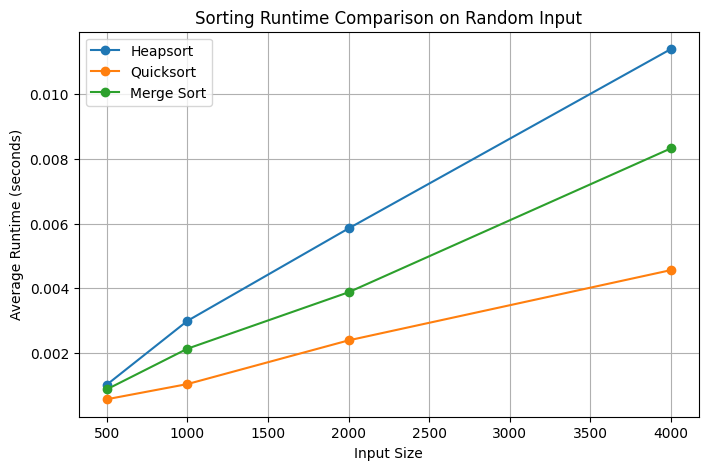

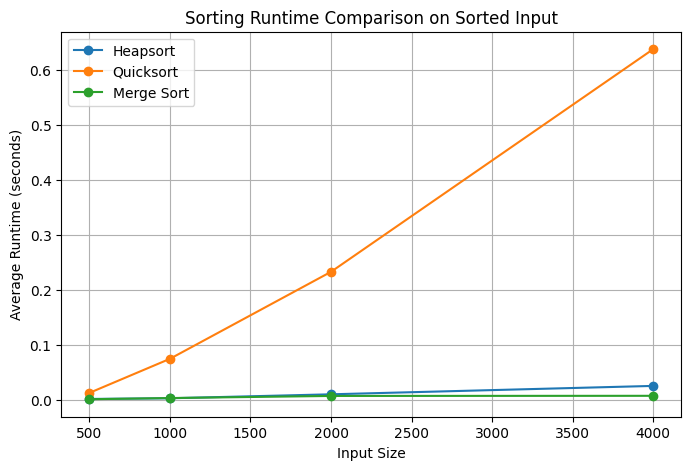

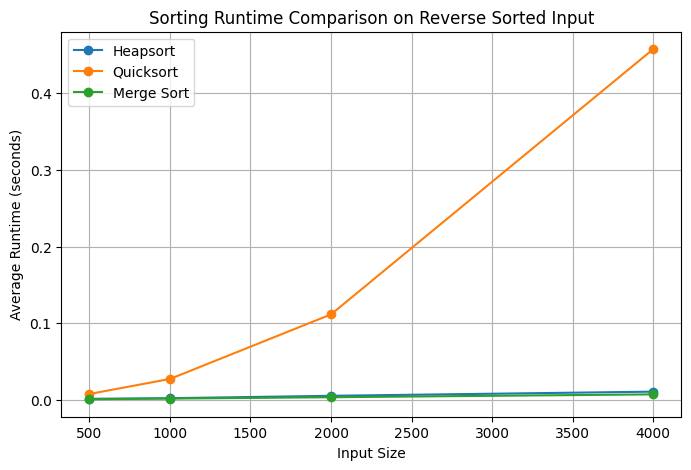

In [7]:
"""
Plot the runtime comparison for each input type.

Each plot compares:
- Heapsort
- Quicksort
- Merge Sort
"""

for input_type in comparison_df["Input Type"].unique():
    subset = comparison_df[comparison_df["Input Type"] == input_type]

    plt.figure(figsize=(8, 5))
    plt.plot(subset["Size"], subset["Heapsort (s)"], marker="o", label="Heapsort")
    plt.plot(subset["Size"], subset["Quicksort (s)"], marker="o", label="Quicksort")
    plt.plot(subset["Size"], subset["Merge Sort (s)"], marker="o", label="Merge Sort")

    plt.title(f"Sorting Runtime Comparison on {input_type} Input")
    plt.xlabel("Input Size")
    plt.ylabel("Average Runtime (seconds)")
    plt.legend()
    plt.grid(True)
    plt.show()

In [8]:
"""
Save the comparison results to a CSV file for GitHub submission.
"""

comparison_df.to_csv("sorting_comparison_results.csv", index=False)
print("Results saved to sorting_comparison_results.csv")

Results saved to sorting_comparison_results.csv


## Interpretation of the Comparison Results

The experimental results should generally show the following pattern:

### Heapsort
Heapsort is expected to remain relatively stable across different input types because its time complexity is \(O(n \log n)\) in the best, average, and worst cases.

### Merge Sort
Merge Sort is also expected to remain stable across input distributions because its recursive splitting and merging process does not depend strongly on the initial ordering of the input.

### Quicksort
Deterministic Quicksort using the first element as the pivot may perform reasonably on some random inputs, but it is expected to become much slower on sorted and reverse-sorted inputs because the partitions become highly unbalanced.

### Overall conclusion
The comparison helps show that Heapsort is more robust than fixed-pivot Quicksort across different input types, while Merge Sort and Heapsort both maintain more predictable \(O(n \log n)\)-style behavior.

## Part 2A: Priority Queue Implementation Using a Binary Heap

In this part, I implemented a **priority queue** using a **binary max-heap** stored in a Python list.

### Design choices

#### 1. Data structure choice
I used a Python list to represent the binary heap because it is the standard and most efficient way to implement a heap. It allows direct index-based access to parent and child nodes:

- left child = \(2i + 1\)
- right child = \(2i + 2\)
- parent = \((i - 1) // 2\)

#### 2. Task representation
I created a `Task` class to represent each task in the scheduler.  
Each task stores:
- `task_id`
- `priority`
- `arrival_time`
- `deadline`
- `description`

#### 3. Max-heap vs min-heap
I chose a **max-heap**, which means the task with the **highest priority** is always at the root and is extracted first.

### Process Followed
I built this part in stages:

1. Defined a `Task` class
2. Implemented a `MaxHeapPriorityQueue` class
3. Added helper methods for:
   - swapping elements
   - bubbling a task upward
   - bubbling a task downward
4. Implemented the required operations:
   - `insert(task)`
   - `extract_max()`
   - `increase_key(task_id, new_priority)`
   - `decrease_key(task_id, new_priority)`
   - `is_empty()`
5. Added correctness tests to verify that the queue behaves as expected

In [9]:
"""
Assignment 4
Part 2A: Priority Queue Implementation Using a Binary Max-Heap

Name: Sai Venkata Bharath Reddy Singareddy

Purpose:
This code implements a priority queue using a binary max-heap stored in a Python list.

What this implementation includes:
1. A Task class to represent tasks
2. A MaxHeapPriorityQueue class
3. Core operations:
   - insert(task)
   - extract_max()
   - increase_key(task_id, new_priority)
   - decrease_key(task_id, new_priority)
   - is_empty()

Design choice:
A Python list is used for the heap because array/list representation is the
standard way to implement a binary heap efficiently.

Heap index formulas:
- left child  = 2*i + 1
- right child = 2*i + 2
- parent      = (i - 1) // 2
"""


class Task:
    """
    Represent a single task in the scheduler.

    Attributes:
        task_id (str): Unique identifier for the task
        priority (int or float): Larger value means higher priority
        arrival_time (int or float): Time at which the task arrives
        deadline (int or float): Deadline associated with the task
        description (str): Optional text description
    """

    def __init__(self, task_id, priority, arrival_time, deadline, description=""):
        """
        Initialize a Task object.
        """
        self.task_id = task_id
        self.priority = priority
        self.arrival_time = arrival_time
        self.deadline = deadline
        self.description = description

    def __repr__(self):
        """
        Return a readable string representation of the task.
        """
        return (
            f"Task(task_id={self.task_id}, priority={self.priority}, "
            f"arrival_time={self.arrival_time}, deadline={self.deadline}, "
            f"description='{self.description}')"
        )


class MaxHeapPriorityQueue:
    """
    Priority queue implementation using a binary max-heap.

    Main idea:
    - The task with the highest priority is stored at the root of the heap.
    - Insertions place the new task at the end, then bubble it upward.
    - Extraction removes the root, replaces it with the last element,
      and then restores the heap property by bubbling downward.
    """

    def __init__(self):
        """
        Initialize an empty priority queue.

        heap:
            List storing Task objects in max-heap order

        position_map:
            Dictionary mapping task_id -> index in heap
            This helps support efficient key updates.
        """
        self.heap = []
        self.position_map = {}

    def is_empty(self):
        """
        Check whether the priority queue is empty.

        Returns:
            bool: True if empty, otherwise False

        Time complexity:
            O(1)
        """
        return len(self.heap) == 0

    def _parent(self, index):
        """
        Return the parent index of a given node.
        """
        return (index - 1) // 2

    def _left_child(self, index):
        """
        Return the left child index of a given node.
        """
        return 2 * index + 1

    def _right_child(self, index):
        """
        Return the right child index of a given node.
        """
        return 2 * index + 2

    def _swap(self, i, j):
        """
        Swap two tasks in the heap and update the position map.

        Parameters:
            i (int): First index
            j (int): Second index
        """
        self.heap[i], self.heap[j] = self.heap[j], self.heap[i]

        # Update task positions after swap
        self.position_map[self.heap[i].task_id] = i
        self.position_map[self.heap[j].task_id] = j

    def _bubble_up(self, index):
        """
        Move a task upward until the max-heap property is restored.

        This is used after insertion or after increasing a task's priority.

        Time complexity:
            O(log n)
        """
        while index > 0:
            parent_index = self._parent(index)

            # If the current task has higher priority than its parent,
            # swap them and continue upward
            if self.heap[index].priority > self.heap[parent_index].priority:
                self._swap(index, parent_index)
                index = parent_index
            else:
                break

    def _bubble_down(self, index):
        """
        Move a task downward until the max-heap property is restored.

        This is used after removing the root or after decreasing a task's priority.

        Time complexity:
            O(log n)
        """
        heap_size = len(self.heap)

        while True:
            largest = index
            left = self._left_child(index)
            right = self._right_child(index)

            # Check left child
            if left < heap_size and self.heap[left].priority > self.heap[largest].priority:
                largest = left

            # Check right child
            if right < heap_size and self.heap[right].priority > self.heap[largest].priority:
                largest = right

            # If the root of this subtree is already largest, stop
            if largest == index:
                break

            # Otherwise swap and continue downward
            self._swap(index, largest)
            index = largest

    def insert(self, task):
        """
        Insert a new task into the priority queue.

        Parameters:
            task (Task): The task to insert

        Behavior:
        - Add the task at the end of the heap
        - Bubble it upward until the heap property is restored

        Time complexity:
            O(log n)
        """
        # Prevent duplicate task IDs
        if task.task_id in self.position_map:
            raise ValueError(f"Task with ID '{task.task_id}' already exists.")

        # Add new task at the end
        self.heap.append(task)
        index = len(self.heap) - 1
        self.position_map[task.task_id] = index

        # Restore heap property
        self._bubble_up(index)

    def extract_max(self):
        """
        Remove and return the task with the highest priority.

        Returns:
            Task: The highest-priority task
            None: If the queue is empty

        Main steps:
        - Remove the root
        - Move the last task to the root
        - Bubble it downward to restore the heap

        Time complexity:
            O(log n)
        """
        if self.is_empty():
            return None

        # If there is only one task, remove and return it directly
        if len(self.heap) == 1:
            max_task = self.heap.pop()
            del self.position_map[max_task.task_id]
            return max_task

        # Save the root task to return later
        max_task = self.heap[0]

        # Move the last task to the root
        last_task = self.heap.pop()
        self.heap[0] = last_task

        # Update position map
        del self.position_map[max_task.task_id]
        self.position_map[last_task.task_id] = 0

        # Restore heap property
        self._bubble_down(0)

        return max_task

    def increase_key(self, task_id, new_priority):
        """
        Increase the priority of an existing task.

        Parameters:
            task_id (str): ID of the task to update
            new_priority (int or float): New larger priority value

        Behavior:
        - Update the task's priority
        - Bubble the task upward if needed

        Time complexity:
            O(log n)
        """
        if task_id not in self.position_map:
            raise KeyError(f"Task ID '{task_id}' not found.")

        index = self.position_map[task_id]
        current_priority = self.heap[index].priority

        if new_priority < current_priority:
            raise ValueError("New priority must be greater than or equal to the current priority.")

        self.heap[index].priority = new_priority
        self._bubble_up(index)

    def decrease_key(self, task_id, new_priority):
        """
        Decrease the priority of an existing task.

        Parameters:
            task_id (str): ID of the task to update
            new_priority (int or float): New smaller priority value

        Behavior:
        - Update the task's priority
        - Bubble the task downward if needed

        Time complexity:
            O(log n)
        """
        if task_id not in self.position_map:
            raise KeyError(f"Task ID '{task_id}' not found.")

        index = self.position_map[task_id]
        current_priority = self.heap[index].priority

        if new_priority > current_priority:
            raise ValueError("New priority must be less than or equal to the current priority.")

        self.heap[index].priority = new_priority
        self._bubble_down(index)

    def peek_max(self):
        """
        Return the highest-priority task without removing it.

        Returns:
            Task or None

        Time complexity:
            O(1)
        """
        if self.is_empty():
            return None
        return self.heap[0]

    def __len__(self):
        """
        Return the number of tasks currently in the priority queue.
        """
        return len(self.heap)

    def __repr__(self):
        """
        Return a readable string representation of the heap.
        """
        return f"MaxHeapPriorityQueue({self.heap})"

In [10]:
"""
Basic correctness tests for the priority queue.

These tests check:
1. insertion
2. peek_max
3. extract_max
4. increase_key
5. decrease_key
6. is_empty
"""

# Create a priority queue
pq = MaxHeapPriorityQueue()

# Create some tasks
task1 = Task("T1", priority=5, arrival_time=0, deadline=10, description="Low priority task")
task2 = Task("T2", priority=15, arrival_time=1, deadline=8, description="High priority task")
task3 = Task("T3", priority=10, arrival_time=2, deadline=12, description="Medium priority task")
task4 = Task("T4", priority=20, arrival_time=3, deadline=6, description="Very high priority task")

# Insert tasks
pq.insert(task1)
pq.insert(task2)
pq.insert(task3)
pq.insert(task4)

print("Priority queue after insertions:")
print(pq)
print()

# Check max
print("Current highest-priority task:")
print(pq.peek_max())
print()

# Increase priority of T1
pq.increase_key("T1", 25)
print("After increasing priority of T1 to 25:")
print(pq)
print("New highest-priority task:")
print(pq.peek_max())
print()

# Decrease priority of T1
pq.decrease_key("T1", 7)
print("After decreasing priority of T1 to 7:")
print(pq)
print("Current highest-priority task:")
print(pq.peek_max())
print()

# Extract tasks in priority order
print("Extracting tasks in priority order:")
while not pq.is_empty():
    print(pq.extract_max())

print()

# Final empty check
print("Is the queue empty?", pq.is_empty())

Priority queue after insertions:
MaxHeapPriorityQueue([Task(task_id=T4, priority=20, arrival_time=3, deadline=6, description='Very high priority task'), Task(task_id=T2, priority=15, arrival_time=1, deadline=8, description='High priority task'), Task(task_id=T3, priority=10, arrival_time=2, deadline=12, description='Medium priority task'), Task(task_id=T1, priority=5, arrival_time=0, deadline=10, description='Low priority task')])

Current highest-priority task:
Task(task_id=T4, priority=20, arrival_time=3, deadline=6, description='Very high priority task')

After increasing priority of T1 to 25:
MaxHeapPriorityQueue([Task(task_id=T1, priority=25, arrival_time=0, deadline=10, description='Low priority task'), Task(task_id=T4, priority=20, arrival_time=3, deadline=6, description='Very high priority task'), Task(task_id=T3, priority=10, arrival_time=2, deadline=12, description='Medium priority task'), Task(task_id=T2, priority=15, arrival_time=1, deadline=8, description='High priority ta

In [11]:
"""
Assert-based tests for stronger correctness checking.
"""

test_pq = MaxHeapPriorityQueue()

test_pq.insert(Task("A", 4, 0, 10))
test_pq.insert(Task("B", 9, 1, 9))
test_pq.insert(Task("C", 6, 2, 8))

# Highest priority should be B
assert test_pq.peek_max().task_id == "B"

# Increase A to highest priority
test_pq.increase_key("A", 12)
assert test_pq.peek_max().task_id == "A"

# Decrease A back down
test_pq.decrease_key("A", 3)
assert test_pq.peek_max().task_id == "B"

# Extract in descending priority order
first = test_pq.extract_max()
second = test_pq.extract_max()
third = test_pq.extract_max()

assert first.task_id == "B"
assert second.task_id == "C"
assert third.task_id == "A"
assert test_pq.is_empty() is True

print("All priority queue tests passed successfully.")

All priority queue tests passed successfully.


## Initial Observation

The priority queue correctly supports all the required heap operations:

- insertion of new tasks
- extraction of the highest-priority task
- increasing the priority of an existing task
- decreasing the priority of an existing task
- checking whether the queue is empty

Using a max-heap makes it easy to model a scheduler where the most important task should be processed first.

## Part 2B: Task Scheduler Simulation Using the Priority Queue

After implementing the priority queue, I used it to simulate a simple task scheduler.

### Scheduling rule used
I chose a **highest-priority-first** scheduling approach because my priority queue is implemented as a **max-heap**.

### Simplifying assumption
For this simulation, I assumed that each task takes **one unit of execution time**.  
This keeps the scheduler easy to understand while still showing how the priority queue is used in an application.

### Process Followed
I built the scheduler in the following steps:

1. Sort all tasks by arrival time
2. Move tasks into the priority queue as they arrive
3. At each time step, extract the highest-priority task
4. Execute that task for one time unit
5. Record:
   - start time
   - completion time
   - waiting time
   - whether the deadline was met

This simulation helps show how heap-based priority queues are useful in real scheduling scenarios.

In [12]:
"""
Part 2B: Scheduler simulation using the heap-based priority queue.

This simulation models a simple highest-priority-first scheduler.

Assumption:
- Each task takes exactly 1 time unit to execute.

Why this assumption is useful:
- It keeps the simulation simple
- It allows the focus to remain on the heap-based priority queue behavior
- It still shows how tasks are selected and scheduled based on priority
"""

import pandas as pd


def simulate_scheduler(tasks):
    """
    Simulate a simple highest-priority-first scheduler.

    Parameters:
        tasks (list of Task): Tasks to schedule

    Returns:
        tuple:
            schedule_df (DataFrame): One row per executed task
            summary_df (DataFrame): High-level scheduler summary

    Main logic:
    - Tasks arrive over time
    - Arrived tasks are inserted into the max-heap priority queue
    - At each time step, the highest-priority task is extracted and executed
    - Each task takes 1 unit of execution time
    """

    # Sort tasks by arrival time so we can add them in chronological order
    tasks_sorted = sorted(tasks, key=lambda task: task.arrival_time)

    # Create a fresh priority queue for the simulation
    scheduler_queue = MaxHeapPriorityQueue()

    # Current time in the scheduler
    current_time = 0

    # Index used to track which tasks have already arrived
    arrival_index = 0

    # Records for detailed execution output
    schedule_records = []

    # Continue until all tasks have arrived and the queue becomes empty
    while arrival_index < len(tasks_sorted) or not scheduler_queue.is_empty():

        # If the queue is empty but future tasks still remain,
        # jump forward to the next task arrival time
        if scheduler_queue.is_empty() and arrival_index < len(tasks_sorted):
            current_time = max(current_time, tasks_sorted[arrival_index].arrival_time)

        # Insert all tasks that have arrived by the current time
        while arrival_index < len(tasks_sorted) and tasks_sorted[arrival_index].arrival_time <= current_time:
            scheduler_queue.insert(tasks_sorted[arrival_index])
            arrival_index += 1

        # If the queue is still empty after checking arrivals, continue
        if scheduler_queue.is_empty():
            continue

        # Extract the highest-priority task
        current_task = scheduler_queue.extract_max()

        # Record execution timing
        start_time = current_time
        completion_time = current_time + 1  # one time unit per task
        waiting_time = start_time - current_task.arrival_time
        turnaround_time = completion_time - current_task.arrival_time
        deadline_met = completion_time <= current_task.deadline
        lateness = max(0, completion_time - current_task.deadline)

        # Save this execution record
        schedule_records.append({
            "Task ID": current_task.task_id,
            "Priority": current_task.priority,
            "Arrival Time": current_task.arrival_time,
            "Deadline": current_task.deadline,
            "Start Time": start_time,
            "Completion Time": completion_time,
            "Waiting Time": waiting_time,
            "Turnaround Time": turnaround_time,
            "Deadline Met": deadline_met,
            "Lateness": lateness,
            "Description": current_task.description
        })

        # Move time forward after executing one task
        current_time = completion_time

    # Convert detailed records into a DataFrame
    schedule_df = pd.DataFrame(schedule_records)

    # Build a summary table
    total_tasks = len(schedule_df)
    tasks_met_deadline = int(schedule_df["Deadline Met"].sum()) if total_tasks > 0 else 0
    tasks_missed_deadline = total_tasks - tasks_met_deadline
    avg_waiting_time = schedule_df["Waiting Time"].mean() if total_tasks > 0 else 0
    avg_turnaround_time = schedule_df["Turnaround Time"].mean() if total_tasks > 0 else 0

    summary_df = pd.DataFrame([{
        "Total Tasks": total_tasks,
        "Tasks Meeting Deadline": tasks_met_deadline,
        "Tasks Missing Deadline": tasks_missed_deadline,
        "Average Waiting Time": avg_waiting_time,
        "Average Turnaround Time": avg_turnaround_time
    }])

    return schedule_df, summary_df

In [13]:
"""
Create sample tasks and run the scheduler simulation.

These tasks are chosen to demonstrate:
- different priorities
- different arrival times
- different deadlines
"""

sample_tasks = [
    Task("T1", priority=4,  arrival_time=0, deadline=3, description="Background logging"),
    Task("T2", priority=10, arrival_time=0, deadline=2, description="Sensor fusion update"),
    Task("T3", priority=7,  arrival_time=1, deadline=5, description="Navigation planning"),
    Task("T4", priority=12, arrival_time=2, deadline=4, description="Emergency obstacle handling"),
    Task("T5", priority=5,  arrival_time=3, deadline=7, description="Map refresh"),
    Task("T6", priority=9,  arrival_time=4, deadline=6, description="Control correction")
]

schedule_df, summary_df = simulate_scheduler(sample_tasks)

print("Detailed scheduler execution results:")
display(schedule_df)

print("\nScheduler summary:")
display(summary_df)

Detailed scheduler execution results:


,Task ID,Priority,Arrival Time,Deadline,Start Time,Completion Time,Waiting Time,Turnaround Time,Deadline Met,Lateness,Description
0,T2,10,0,2,0,1,0,1,True,0,Sensor fusion update
1,T3,7,1,5,1,2,0,1,True,0,Navigation planning
2,T4,12,2,4,2,3,0,1,True,0,Emergency obstacle handling
3,T5,5,3,7,3,4,0,1,True,0,Map refresh
4,T6,9,4,6,4,5,0,1,True,0,Control correction
5,T1,4,0,3,5,6,5,6,False,3,Background logging



Scheduler summary:


,Total Tasks,Tasks Meeting Deadline,Tasks Missing Deadline,Average Waiting Time,Average Turnaround Time
0,6,5,1,0.833333,1.833333


In [14]:
"""
Optional: Save the scheduler results to CSV files for GitHub submission.
"""

schedule_df.to_csv("scheduler_execution_results.csv", index=False)
summary_df.to_csv("scheduler_summary_results.csv", index=False)

print("Saved:")
print("- scheduler_execution_results.csv")
print("- scheduler_summary_results.csv")

Saved:
- scheduler_execution_results.csv
- scheduler_summary_results.csv


## Interpretation of the Scheduler Results

The simulation shows how a heap-based priority queue can be used to schedule tasks efficiently.

### What the results show
- Tasks are inserted into the queue when they arrive
- At each step, the task with the highest priority is selected first
- Waiting time depends on both arrival time and the priorities of competing tasks
- Deadline satisfaction depends on whether high-priority scheduling aligns well with deadline order

### Main takeaway
The binary heap makes task selection efficient because the highest-priority task is always available at the root of the heap. This makes the priority queue a natural choice for scheduling systems where tasks must be processed according to importance.

## Part 2C: Time Complexity Analysis of Priority Queue Operations

After implementing the heap-based priority queue and using it in a scheduler simulation, I analyzed the time complexity of the main operations.

The priority queue is implemented using a **binary max-heap** stored in a Python list.  
Because a binary heap is a complete binary tree, its height is:

\[
O(\log n)
\]

where \(n\) is the number of tasks currently stored in the heap.

This height is important because most heap operations involve moving a task up or down along one root-to-leaf path.

## Time Complexity of `insert(task)`

To insert a new task into the priority queue:

1. the task is first placed at the end of the heap,
2. then it is moved upward until the max-heap property is restored.

Placing the task at the end takes:

\[
O(1)
\]

The upward movement, often called **bubble-up** or **heapify-up**, may move through at most the height of the heap, which is:

\[
O(\log n)
\]

Therefore, the total time complexity of `insert(task)` is:

\[
O(\log n)
\]

### Intuition
In the worst case, a newly inserted task has the highest priority and must move all the way from the bottom of the heap to the root.

## Time Complexity of `extract_max()`

In a max-heap, the highest-priority task is always stored at the root.

To perform `extract_max()`:

1. remove the root task,
2. move the last task in the heap to the root position,
3. move that task downward until the max-heap property is restored.

Removing the root and replacing it with the last element takes constant time:

\[
O(1)
\]

The downward adjustment, often called **bubble-down** or **heapify-down**, may move through at most the height of the heap, which is:

\[
O(\log n)
\]

So the total time complexity of `extract_max()` is:

\[
O(\log n)
\]

### Intuition
In the worst case, the element moved to the root may need to travel all the way down to a leaf.

## Time Complexity of `increase_key(task_id, new_priority)`

When increasing the priority of an existing task:

1. locate the task in the heap,
2. update its priority value,
3. move it upward if necessary.

In my implementation, I used a `position_map` dictionary that stores the current index of each task in the heap.  
Because of this, locating the task by `task_id` takes expected:

\[
O(1)
\]

Updating the priority itself is also:

\[
O(1)
\]

After that, the task may need to move upward through the heap, which takes at most:

\[
O(\log n)
\]

Therefore, the total time complexity of `increase_key()` is:

\[
O(\log n)
\]

### Why the dictionary helps
Without the `position_map`, the algorithm would need to scan the heap linearly to find the task, which would take \(O(n)\).  
Using the map improves the update operation significantly.

## Time Complexity of `decrease_key(task_id, new_priority)`

When decreasing the priority of an existing task:

1. locate the task,
2. update its priority,
3. move it downward if necessary.

As in `increase_key()`, locating the task through the `position_map` takes expected:

\[
O(1)
\]

Updating the value takes:

\[
O(1)
\]

The downward movement through the heap takes at most:

\[
O(\log n)
\]

So the total time complexity of `decrease_key()` is:

\[
O(\log n)
\]

## Time Complexity of `is_empty()`

The `is_empty()` operation only checks whether the heap contains any tasks.

This requires only checking the length of the underlying list, so its time complexity is:

\[
O(1)
\]

This makes it a very efficient operation.

## Overall Complexity Summary

For the heap-based priority queue implemented in this assignment, the main operations have the following time complexities:

- `insert(task)` : \(O(\log n)\)
- `extract_max()` : \(O(\log n)\)
- `increase_key(task_id, new_priority)` : \(O(\log n)\)
- `decrease_key(task_id, new_priority)` : \(O(\log n)\)
- `is_empty()` : \(O(1)\)

These results are expected for binary heaps because the height of the heap is \(O(\log n)\), and the main operations restore heap order by moving along a single path in the tree.

## Why a Heap is a Good Choice for Scheduling

A scheduler often needs to repeatedly select the next most important task.

A heap is a good choice for this because:

- insertion of newly arrived tasks is efficient,
- extraction of the highest-priority task is efficient,
- priority updates are efficient,
- the next task is always available at the root.

This makes a binary heap well suited for systems where task priorities change over time and fast selection is important.

## Discussion of the Scheduler Results

In the simulation, tasks were inserted into the priority queue when they arrived, and the scheduler always selected the task with the highest priority first.

### What this means
This scheduling approach favors importance over arrival order.  
As a result:

- high-priority tasks tend to be executed quickly,
- lower-priority tasks may wait longer,
- some deadlines may be missed if many urgent tasks arrive close together.

### Relation to the heap
The scheduler can make these decisions efficiently because the binary max-heap keeps the highest-priority task at the root.

### Practical interpretation
This kind of scheduling can be useful in systems where urgent or safety-critical tasks must be handled before less important background tasks.

## Conclusion for Part 2

The heap-based priority queue supports all required operations efficiently.

Because the binary heap has height \(O(\log n)\), the main update and extraction operations take logarithmic time, while checking whether the queue is empty takes constant time.

The scheduler simulation also showed why heaps are useful in practice: they allow fast task insertion and fast selection of the next highest-priority task, which makes them a natural fit for scheduling applications.